# Error rates verification

In this notebook I generate all the datasets needed to check the different error rates, as asked in the review. Lets take it step by step

## Generating radiometries

First step is to generate radiometries with the error rates mentioned.

In [3]:
import numpy as np
import pandas as pd
import os
import shutil
import matplotlib.pyplot as plt

In [4]:
whatprot_path= "/../../ext/whatprot/cc_code/bin/release/whatprot"
common_path_datasets= "/raid/jkipen/ProtInfGPU/data/WhatprotGen/Review/"
dye_seqs_path=common_path_datasets + "dye-seqs.tsv"
Div2_path=common_path_datasets+"Div2/";Div5_path=common_path_datasets+"Div5/";Div10_path=common_path_datasets+"Div10/";
Divs_paths=[Div2_path,Div5_path,Div10_path];
ErrParamsJsonFile="ErrParams.json"
n_samples_per_dataset=10000000; 
n_multidatasets=10;

In [6]:
n_samples_per_dataset=10000000; 
n_multidatasets=10;
#for j in range(len(Divs_paths)):
for j in range(1,3): #We start with only doing the process for one path to check!
    div_path=Divs_paths[j];
    for i in range(n_multidatasets):
        param_path=div_path+ErrParamsJsonFile;
        rad_path = div_path+ "MultiDatasets/radiometries_"+str(i)+".tsv";
        true_ids_path = div_path+ "MultiDatasets/true-ids_"+str(i)+".tsv";
        command = "." +whatprot_path + " simulate rad -t 40 -g "+str(n_samples_per_dataset) +" -P "+ param_path+" -S "+dye_seqs_path+" -R "+rad_path+" -Y "+true_ids_path;
        print(command)
        os.system(command)

./../../ext/whatprot/cc_code/bin/release/whatprot simulate rad -t 40 -g 10000000 -P /raid/jkipen/ProtInfGPU/data/WhatprotGen/Review/Div5/ErrParams.json -S /raid/jkipen/ProtInfGPU/data/WhatprotGen/Review/dye-seqs.tsv -R /raid/jkipen/ProtInfGPU/data/WhatprotGen/Review/Div5/MultiDatasets/radiometries_0.tsv -Y /raid/jkipen/ProtInfGPU/data/WhatprotGen/Review/Div5/MultiDatasets/true-ids_0.tsv
Finished basic setup (0.000334607 seconds).
Read 152291 dye seqs (0.142627 seconds).
Finished generating 9900112 radiometries (270.875seconds).
Finished saving results (1930.28 seconds).
Total run time: 2201.3 seconds.
./../../ext/whatprot/cc_code/bin/release/whatprot simulate rad -t 40 -g 10000000 -P /raid/jkipen/ProtInfGPU/data/WhatprotGen/Review/Div5/ErrParams.json -S /raid/jkipen/ProtInfGPU/data/WhatprotGen/Review/dye-seqs.tsv -R /raid/jkipen/ProtInfGPU/data/WhatprotGen/Review/Div5/MultiDatasets/radiometries_1.tsv -Y /raid/jkipen/ProtInfGPU/data/WhatprotGen/Review/Div5/MultiDatasets/true-ids_1.tsv
F

In [ ]:
n_dye_seqs = 152291; #Can be read from the file dye-seqs.tsv!

#with open("path/to/file.tsv") as f:
#    f.readline()           # skip first line (N_colors)
#    n_dyes = int(f.readline().strip())  # read second line (N_dyes)
#print(n_dyes)

In [18]:
#div_path=Divs_paths[0];
#dfr = pd.read_csv(div_path+ "Reduced/radiometries.tsv", sep="\t", header=None, skiprows=3,nrows=10); #Skipping metadata rows
#dfr

div_path=Divs_paths[0];
with open(div_path+ "Reduced/radiometries.tsv") as f:
    for i in range(5):
        print(f.readline())
        
div_path=Divs_paths[0];
with open("/raid/jkipen/ProtInfGPU/data/WhatprotGen/WholeProteomeTests/ProbeamPaperParams/Reduced/radiometries.tsv") as f:
    for i in range(5):
        print(f.readline())

40

3

304582

10069.758687912718	38.323853857574335	10723.627654757289	10305.42680476991	-48.138486650269535	10520.93827341291	8913.337896928297	128.87970403646955	8873.631323363432	10697.424056020693	2.3052094900930267	9600.614276452225	52.25992529973785	-85.58311281210979	101.24875396537162	-1.1946271567763456	19.28136505435295	88.13889911597353	-2.4181459846984814	27.06426510787299	40.89714805588608	120.62394230358464	42.98607661811949	-75.07965160978355	-118.3164993413629	73.6958989398571	113.06637181222209	-91.19468284358607	-5.606430995453392	27.285023635792708	3.2803178684135936	0.0995086336101902	18.69526780173636	-102.11240607289815	24.67790519482501	2.4944066931155726	-96.23749600835758	46.686674503249165	5.846275712159165	104.01749807270298	-57.32710864362798	32.01989870923369	118.83393787637657	-53.49791523124991	-9.010045441070067	98.39912270914125	39.26399001984388	-32.98364336582725	3.6882934583977423	61.60609248941316	-51.3873356003123	55.751917707286026	35.68553336714

In [ ]:
#Do this for each dataset, grabs much memory.
div_path=Divs_paths[0];
dfs = [] 
#for i in range(n_multidatasets):  #Groups multidatasets in one big dataset
#    dfr = pd.read_csv(div_path+ "MultiDatasets/radiometries_"+str(i)+".tsv", sep="\t", header=None, skiprows=3); #Skipping metadata rows
#    dft = pd.read_csv(div_path+ "MultiDatasets/true-ids_"+str(i)+".tsv", sep="\t", header=None, skiprows=1); #Skipping metadata rows
#    dfr['true_ids'] = dft[0]
#    dfs.append(dfr)
#    
#result_df = pd.concat(dfs, axis=0, ignore_index=True)
#result_df = result_df.groupby('true_ids', group_keys=False).apply(lambda group: group.head(100)) #Saves only 100 samples per dye seq.

for i in range(n_multidatasets):  #Groups multidatasets in one big dataset
    print("Analyzing multidataset " + str(i))
    dfr = pd.read_csv(div_path+ "MultiDatasets/radiometries_"+str(i)+".tsv", sep="\t", header=None, skiprows=3); #Skipping metadata rows
    dft = pd.read_csv(div_path+ "MultiDatasets/true-ids_"+str(i)+".tsv", sep="\t", header=None, skiprows=1); #Skipping metadata rows
    dfr['true_ids'] = dft[0]
    dfs.append(dfr)
    result_df = pd.concat(dfs, axis=0, ignore_index=True)
    result_df = result_df.groupby('true_ids', group_keys=False).apply(lambda group: group.head(100))
    dfs=[result_df];
    print("Number of samples per fluseq gotten: " + str(len(result_df)))
            
                                                            
#result_df = pd.concat(dfs, axis=0, ignore_index=True)
#result_df = result_df.groupby('true_ids', group_keys=False).apply(lambda group: group.head(100)) #Saves only 100 samples per dye seq.


result_df.to_csv(div_path+"aux.csv", index=False)

radiometries_df = result_df.drop(columns=['true_ids'])
true_ids_series = result_df['true_ids']

# Get the number of reads (rows) from the filtered data
num_reads = len(result_df)
# Save the final radiometries file with custom header
num_timesteps = 40   # Given constant: number of timesteps
num_channels = 3     # Given constant: number of channels
# Save the final true IDs file with custom header (only number of reads)
true_ids_output_file = div_path+"true-ids.tsv"
with open(true_ids_output_file, "w") as f:
    f.write(f"{num_reads}\n")
    true_ids_series.to_csv(f, sep="\t", index=False, header=False)
    
radiometries_output_file = div_path+"radiometries.tsv"
with open(radiometries_output_file, "w") as f:
    f.write(f"{num_timesteps}\n")
    f.write(f"{num_channels}\n")
    f.write(f"{num_reads}\n")
    radiometries_df.to_csv(f, sep="\t", index=False, header=False)
##Now lets do the reduced dataset
reduced_path=div_path+"Reduced/"; #We will saved the reduced in other folder
df_small = result_df.groupby('true_ids', group_keys=False).apply(lambda group: group.head(2))
num_reads = len(df_small) #Update number of points

radiometries_df_s = df_small.drop(columns=['true_ids'])
true_ids_series_s = df_small['true_ids']

true_ids_output_file = reduced_path+"true-ids.tsv"
with open(true_ids_output_file, "w") as f:
    f.write(f"{num_reads}\n")
    true_ids_series_s.to_csv(f, sep="\t", index=False, header=False)
    
radiometries_output_file = reduced_path+"radiometries.tsv"
with open(radiometries_output_file, "w") as f:
    f.write(f"{num_timesteps}\n")
    f.write(f"{num_channels}\n")
    f.write(f"{num_reads}\n")
    radiometries_df_s.to_csv(f, sep="\t", index=False, header=False)

Analyzing multidataset 0
Number of samples per fluseq gotten: 9735235
Analyzing multidataset 1


In [ ]:
del result_df
del radiometries_df
del true_ids_series

## Run Probeam on radiometries
Now we get the sparse scores with Probeam:

In [15]:
probeam_exec_names=["probeamDiv2","probeamDiv5","probeamDiv10"] #A name for each with reduced error. 
probeam_exec_folder="../../ext/probeam/"

div_index=0;

div_path = Divs_paths[div_index]; #Select err div we want.
probeam_exec = probeam_exec_folder + probeam_exec_names[div_index];

rads_path=div_path+"radiometries.tsv"
reduced_rads_path=div_path+"Reduced/radiometries.tsv"
#Commands to run probeam on df and reduced df:
print(probeam_exec + " "  + rads_path + " -b 30 -s 1000")
print(probeam_exec + " "  + reduced_rads_path + " -b 30 -s 1000")

#./probeamDiv2 /raid/jkipen/ProtInfGPU/data/WhatprotGen/Review/Div2/Reduced/ -b 90 -s 1000

../../ext/probeam/probeamDiv2 /raid/jkipen/ProtInfGPU/data/WhatprotGen/Review/Div2/radiometries.tsv -b 30 -s 1000
../../ext/probeam/probeamDiv2 /raid/jkipen/ProtInfGPU/data/WhatprotGen/Review/Div2/Reduced/radiometries.tsv -b 30 -s 1000


Running this code accordingly we get TopScores & TopScoresId for each div (and reduced).

## Generating datasets for protein inference check

Generate first the datasets by running DatasetExporterWhatprot in code/exporting. I have modified below to make it with the data for this project itself. 

Then run the Oracle with these new datasets: 

In [ ]:
#./opt.out /raid/jkipen/ProtInfGPU/data/Reviews/ErrRates/Div2/binary/ProbeamW2 /home/jkipen/ProtInfGPU/results/Review/Div2Red -d 0 -e 30 -c 1 -m 120 -M 30 -t 1024 -o 1 -n 1000

Once it is working and seems fine, copy the TopNscores and TpoNScoresIds into the respective folders with:

In [ ]:
#Reduced
cp /raid/jkipen/ProtInfGPU/data/WhatprotGen/Review/Div2/Reduced/TopNScores.bin /raid/jkipen/ProtInfGPU/data/Reviews/ErrRates/Div2/binary/ProbeamW2/Common/TopNScores.bin
cp /raid/jkipen/ProtInfGPU/data/WhatprotGen/Review/Div2/Reduced/TopNScoresId.bin /raid/jkipen/ProtInfGPU/data/Reviews/ErrRates/Div2/binary/ProbeamW2/Common/TopNScoresId.bin

#Full
cp /raid/jkipen/ProtInfGPU/data/WhatprotGen/Review/Div2/TopNScores.bin /raid/jkipen/ProtInfGPU/data/Reviews/ErrRates/Div2/binary/ProbeamW100/Common/TopNScores.bin
cp /raid/jkipen/ProtInfGPU/data/WhatprotGen/Review/Div2/TopNScoresId.bin /raid/jkipen/ProtInfGPU/data/Reviews/ErrRates/Div2/binary/ProbeamW100/Common/TopNScoresId.bin

Finally run the full protein inference with

In [ ]:
./opt.out /home/jkipen/raid_storage/ProtInfGPU/data/20642_Prot/binary/ProbeamBetterConfig /home/jkipen/ProtInfGPU/results/20642_Prot/Tests -d 0 -e 3 -c 1 -m 120 -M 30 -t 1024 -n 1000

Now everything has run, lets make the plot!

In [26]:
def get_min_MAE(path):
    return np.min(pd.read_csv(path)["Error mean"].to_numpy())
div2_err=get_min_MAE("/home/jkipen/ProtInfGPU/results/Review/Div2Red/ProbeamW2/31-10-2025_13-41-28/ErrVsEpochs.csv")
div5_err=get_min_MAE("/home/jkipen/ProtInfGPU/results/Review/Div5Red/ProbeamW2/31-10-2025_13-40-52/ErrVsEpochs.csv")
div10_err=get_min_MAE("/home/jkipen/ProtInfGPU/results/Review/Div10Red/ProbeamW2/31-10-2025_13-38-08/ErrVsEpochs.csv")
div1_err=get_min_MAE("/home/jkipen/ProtInfGPU/results/20642_Prot/ProbeamW100/NSpar1000Run/ErrVsEpochs.csv")
div100_err=get_min_MAE("/home/jkipen/ProtInfGPU/results/20642_Prot/ProbeamBetterConfigW100/NSpar1000Run/ErrVsEpochs.csv")
u_err=3.6e-5
oracle_err=get_min_MAE("/home/jkipen/ProtInfGPU/results/20642_Prot/ProbeamBetterConfigW100/Oracle/ErrVsEpochs.csv")

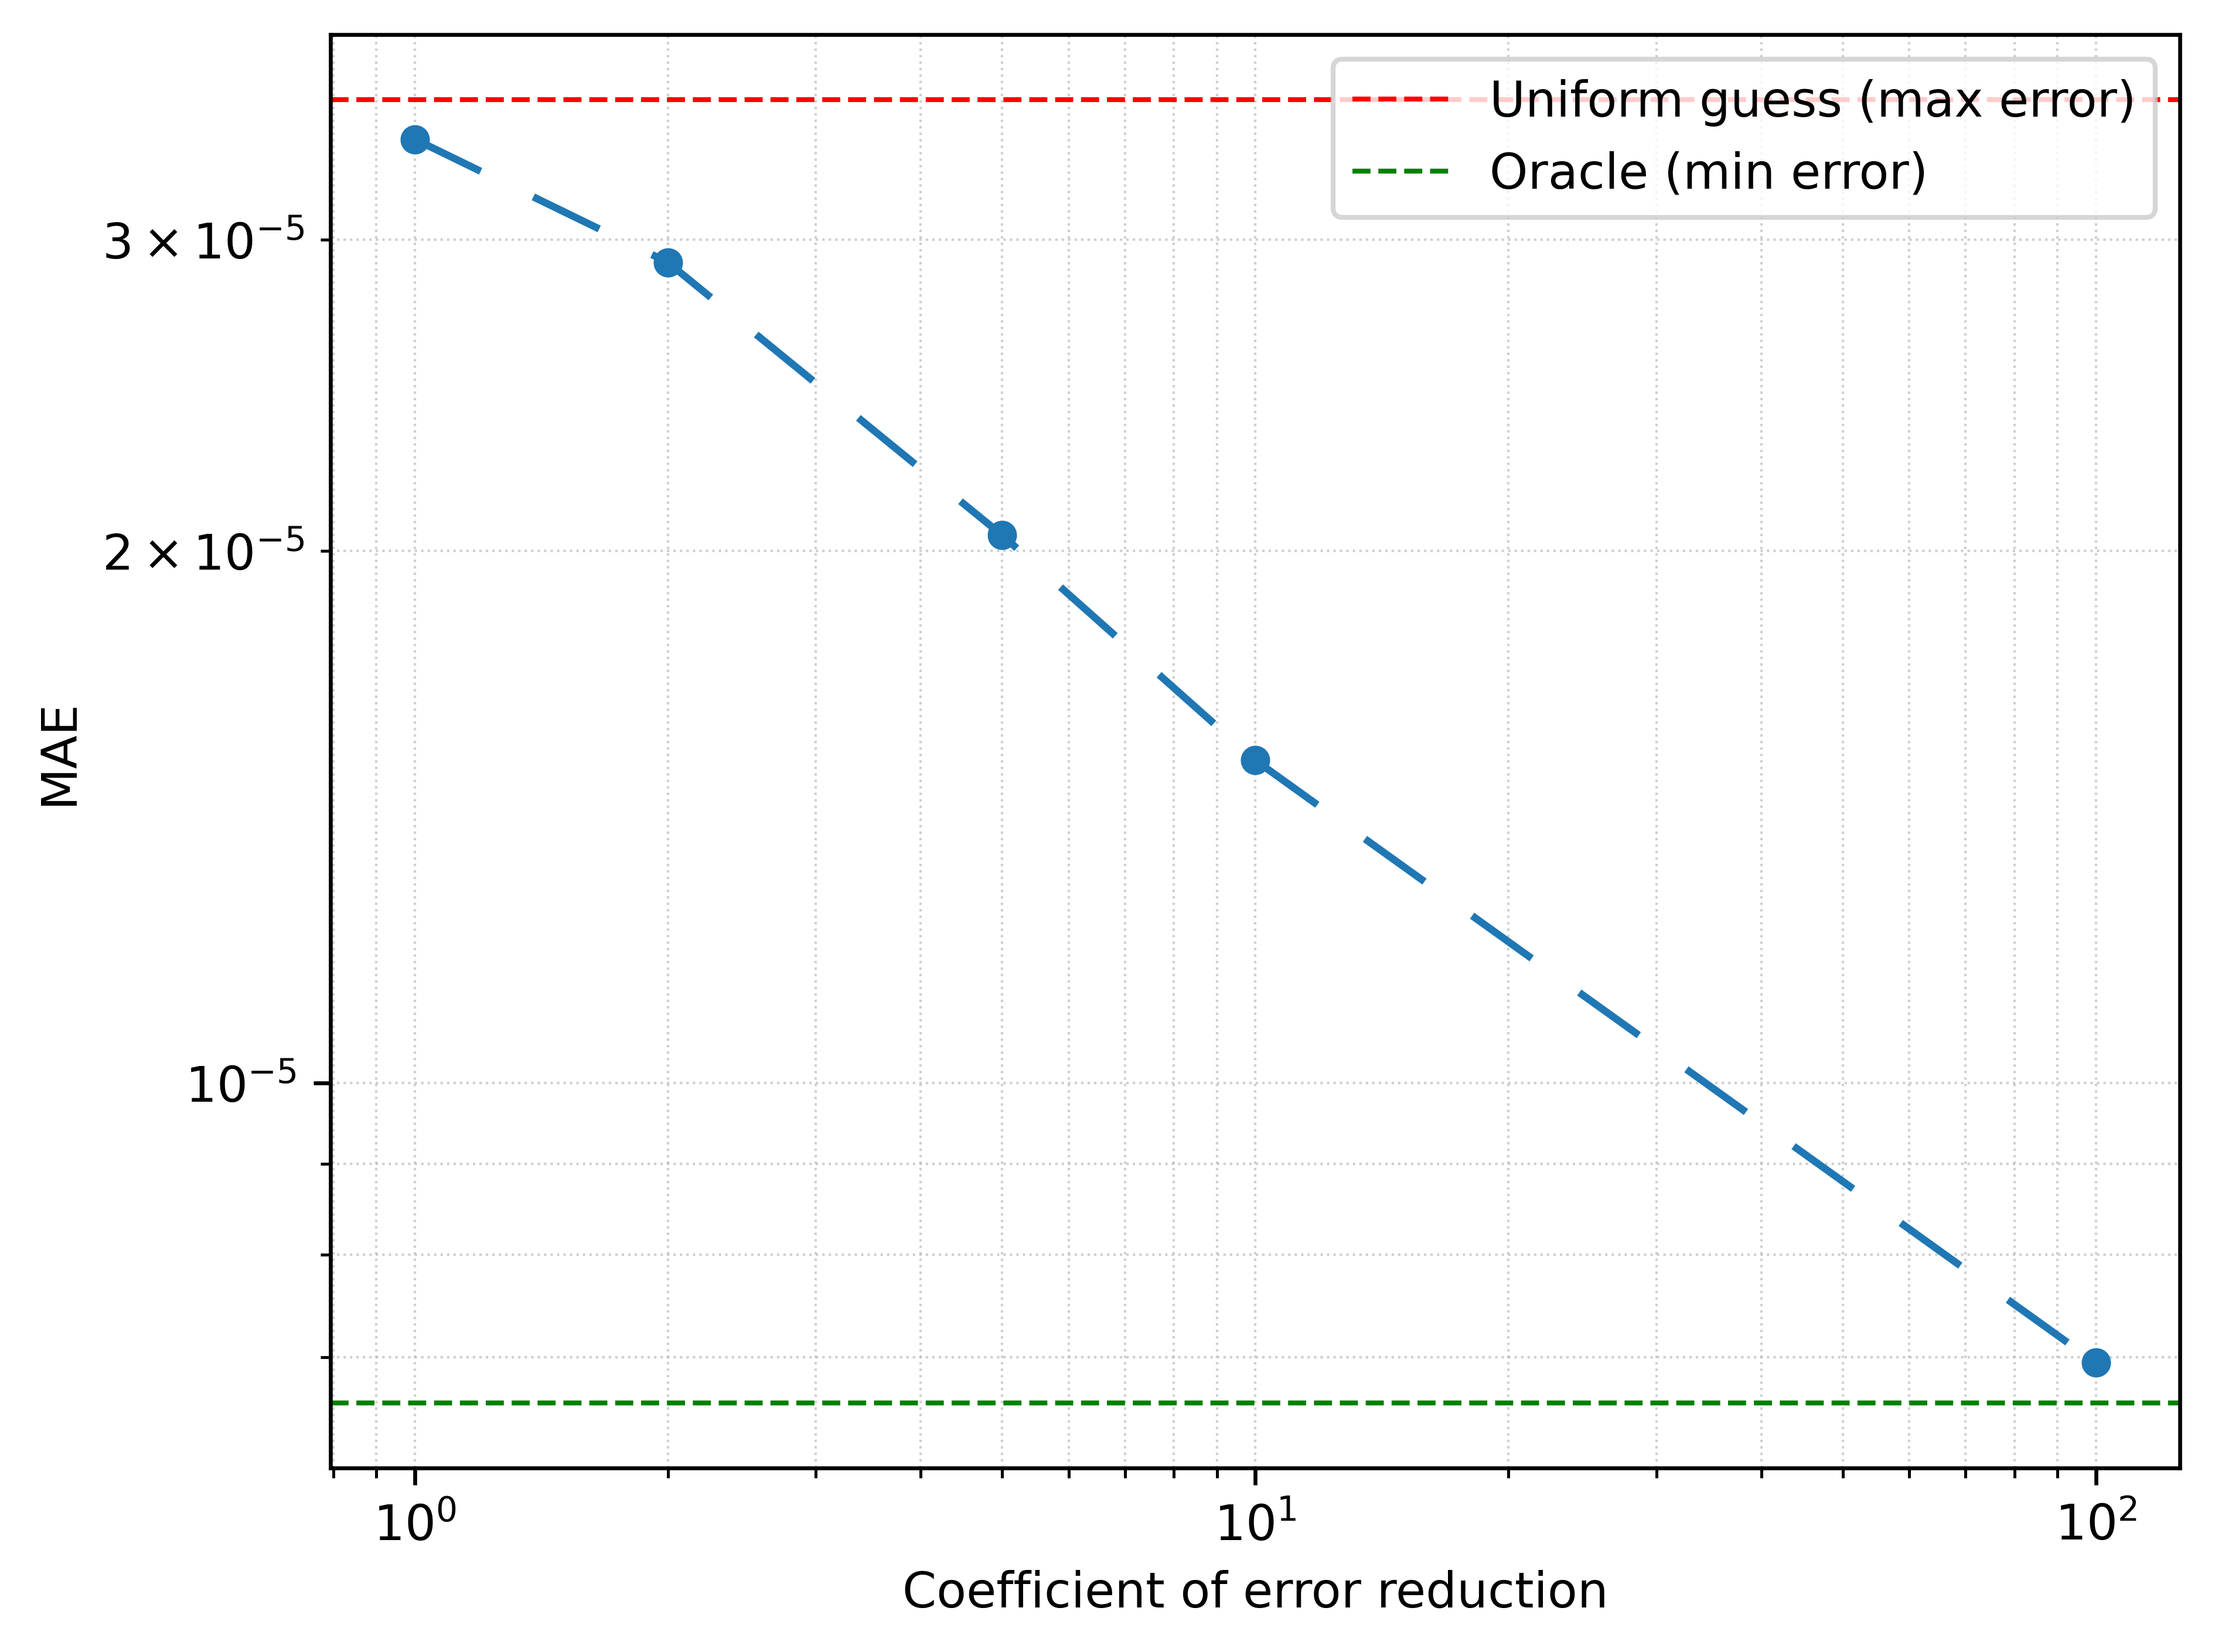

In [29]:
x_vals = np.array([1, 2, 5, 10, 100], dtype=float)
y_vals = np.array([div1_err, div2_err, div5_err, div10_err, div100_err], dtype=float)

plt.figure(dpi=600)

# Main curve with markers and widely spaced dashes
line, = plt.plot(
    x_vals, y_vals,
    linestyle='--', marker='o', linewidth=1.5, markersize=5
)
# Make the dashes more widely spaced: (dash_len, gap_len)
line.set_dashes([10, 8])

# Horizontal reference lines (dashed)
plt.axhline(u_err,      color='red',  linestyle='--', linewidth=1, label='Uniform guess (max error)')
plt.axhline(oracle_err, color='green', linestyle='--', linewidth=1, label='Oracle (min error)')

# Log–log scales
plt.xscale('log')
plt.yscale('log')

# Labels and minimal styling
plt.xlabel("Coefficient of error reduction")
plt.ylabel("MAE")
plt.grid(True, which='both', linestyle=':', linewidth=0.5, alpha=0.6)
plt.legend()

plt.tight_layout()
# Optional: save to file
plt.savefig("mae_vs_coeff_reduction.png")
plt.show()